In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.stats.multitest import multipletests

In [2]:
df = pd.read_csv("/scratch1/smaruj/CTCF_elimination/gamma_300.0/successful_optimizations.tsv", sep="\t")

In [3]:
df

,chrom,fold,PearsonR,centered_start,centered_end,centered_flat_start,centered_flat_end,active_fraction,neutral_fraction,repressive_fraction,...,GC_seq,GC_slice,GC_slice_edited,init_CTCFs_num,CTCFs_num,FIMO_sum,FIMO_max,orientation,positions,URQ_delta
0,chr1,0,0.861165,37799936,39110656,192,320,0.391304,0.521739,0.086957,...,0.439010,0.459961,0.480469,0,0,0.0,0.0,no,(),-0.016288
1,chr3,0,0.670098,38524928,39835648,144,368,0.483871,0.516129,0.000000,...,0.404138,0.437988,0.458984,0,0,0.0,0.0,no,(),-0.164062
2,chr3,0,0.676442,119885824,121196544,154,358,0.500000,0.500000,0.000000,...,0.400891,0.408203,0.472656,1,0,0.0,0.0,no,(),-0.156949
3,chr3,0,0.681364,101859328,103170048,202,310,0.371429,0.514286,0.114286,...,0.433645,0.433594,0.436035,0,0,0.0,0.0,no,(),-0.073462
4,chr3,0,0.684073,99010560,100321280,163,349,0.476190,0.523810,0.000000,...,0.410239,0.428711,0.455566,0,0,0.0,0.0,no,(),-0.042994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,chrX,7,0.763038,159137792,160448512,202,310,0.000000,1.000000,0.000000,...,0.408269,0.414062,0.468750,0,0,0.0,0.0,no,(),-0.097471
328,chrX,7,0.767624,157673472,158984192,197,315,0.454545,0.545455,0.000000,...,0.381405,0.354004,0.381836,0,0,0.0,0.0,no,(),-0.109651
329,chrX,7,0.783571,166264832,167575552,201,311,0.444444,0.555556,0.000000,...,0.408750,0.369141,0.429199,1,0,0.0,0.0,no,(),-0.054517
330,chrX,7,0.804644,144232448,145543168,195,317,0.466667,0.533333,0.000000,...,0.392442,0.345215,0.416016,0,0,0.0,0.0,no,(),-0.151241


In [4]:
flank = (100000 - 2048) // 2

In [5]:
from scipy.stats import pearsonr, wilcoxon

In [6]:
mean_diffs = []
max_diffs = []

max_before = []
max_after = []

mean_signed_diffs = []
max_signed_diffs = []

correlations = []
all_diffs = []  # store per-sequence difference vectors

pvals = []

for i, row in df.iterrows():
    chrom = row['chrom']
    centered_start = int(row['centered_start'])
    centered_end = int(row['centered_end'])
    
    orig = np.load(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/original_preds/{chrom}_{centered_start}_{centered_end}_original.npy")[0, 0, flank:-flank] 
    opt = np.load(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/optimized_preds/{chrom}_{centered_start}_{centered_end}_optimized.npy")[0, 0, flank:-flank]
    
    diff = opt - orig
    all_diffs.append(diff)
    
    max_before.append(np.max(orig))
    max_after.append(np.max(opt))
    
    # direction-aware stats
    mean_signed_diffs.append(np.mean(diff))
    max_signed_diffs.append(np.max(diff))
    
    mean_diffs.append(np.mean(np.abs(diff)))
    max_diffs.append(np.max(np.abs(diff)))
    correlations.append(pearsonr(orig, opt)[0])
    
    # Wilcoxon test across all positions in the sequence
    stat, pval = wilcoxon(opt, orig)
    pvals.append(pval)

In [7]:
df["mean_signed_diff"] = mean_signed_diffs
df["max_signed_diff"]   = max_signed_diffs

df["max_before"] = max_before
df["max_after"] = max_after

df["mean_abs_diff"]     = mean_diffs
df["max_abs_diff"]      = max_diffs
df["correlation"]       = correlations
df["pval"]              = pvals

In [8]:
from statsmodels.stats.multitest import multipletests

# FDR correction
reject, pvals_corrected, _, _ = multipletests(pvals, method="fdr_bh")

df["pval_raw"]       = pvals
df["pval_corrected"] = pvals_corrected
df["reject_null"]    = reject  # True if significant after correction

In [9]:
sum(reject)

311

In [10]:
def classify_change(mean_diff, reject):
    if not reject:
        return "no_change"
    elif mean_diff >= 0:
        return "increased"
    else:  # mean_diff <= 0
        return "decreased"

df["change_category"] = [
    classify_change(m, r) for m, r in zip(df["mean_signed_diff"], df["reject_null"])
]

In [11]:
import seaborn as sns

/tmp/SLURM_1708899/ipykernel_196793/2986821727.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=["#4daf4a","#e41a1c","#999999"])


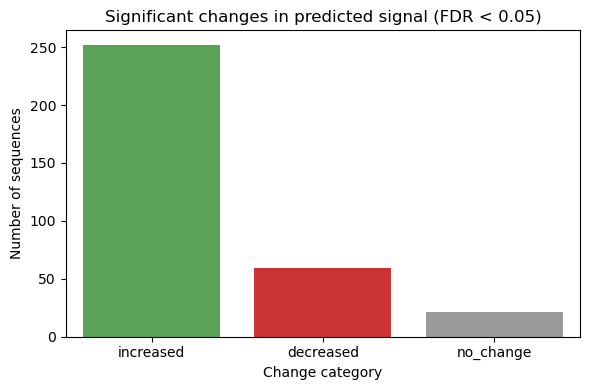

In [12]:
# Count categories
counts = df["change_category"].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values, palette=["#4daf4a","#e41a1c","#999999"])
plt.ylabel("Number of sequences")
plt.xlabel("Change category")
plt.title("Significant changes in predicted signal (FDR < 0.05)")
plt.tight_layout()
plt.show()

In [13]:
# Convert to array for pile-up
all_diffs = np.vstack(all_diffs)  # shape: (n_sequences, 2048)
avg_diff = np.mean(all_diffs, axis=0)      # average difference profile
sem_diff = np.std(all_diffs, axis=0) / np.sqrt(all_diffs.shape[0])  # SEM for shading

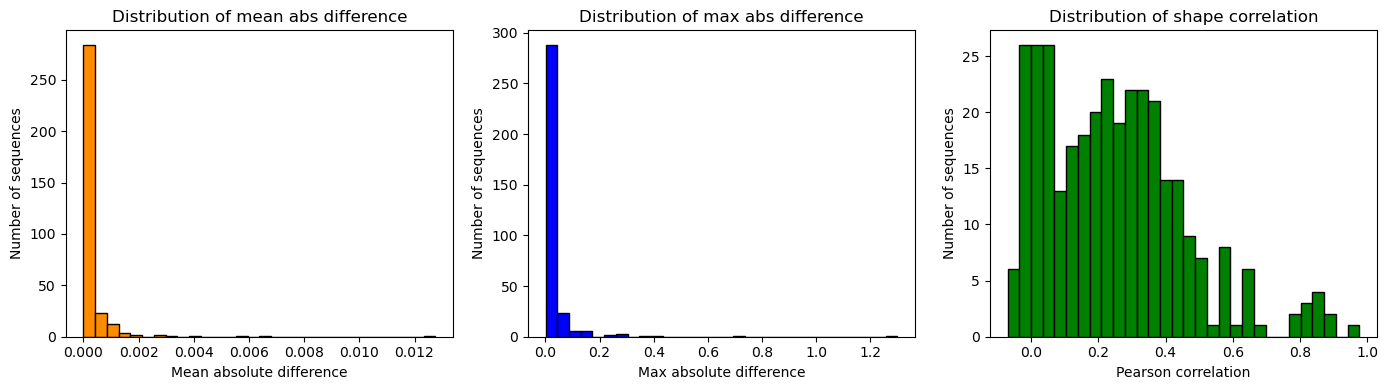

In [14]:
plt.figure(figsize=(14,4))

# Mean absolute differences
plt.subplot(1,3,1)
plt.hist(mean_diffs, bins=30, color="darkorange", edgecolor="black")
plt.xlabel("Mean absolute difference")
plt.ylabel("Number of sequences")
plt.title("Distribution of mean abs difference")

# Max absolute differences
plt.subplot(1,3,2)
plt.hist(max_diffs, bins=30, color="blue", edgecolor="black")
plt.xlabel("Max absolute difference")
plt.ylabel("Number of sequences")
plt.title("Distribution of max abs difference")

# Correlations
plt.subplot(1,3,3)
plt.hist(correlations, bins=30, color="green", edgecolor="black")
plt.xlabel("Pearson correlation")
plt.ylabel("Number of sequences")
plt.title("Distribution of shape correlation")

plt.tight_layout()
plt.show()

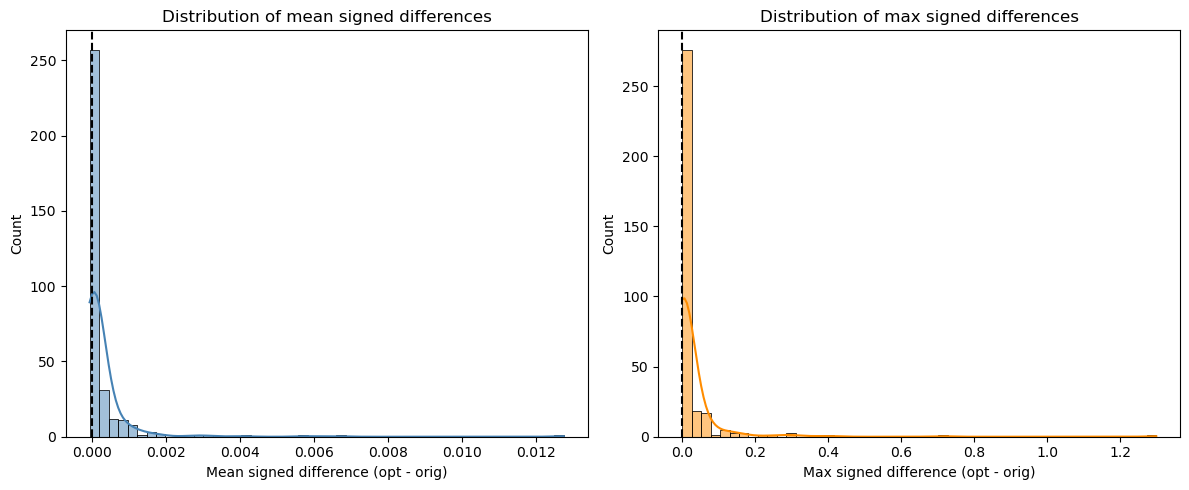

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["mean_signed_diff"], bins=50, kde=True, color="steelblue")
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Mean signed difference (opt - orig)")
plt.ylabel("Count")
plt.title("Distribution of mean signed differences")

plt.subplot(1,2,2)
sns.histplot(df["max_signed_diff"], bins=50, kde=True, color="darkorange")
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Max signed difference (opt - orig)")
plt.ylabel("Count")
plt.title("Distribution of max signed differences")

plt.tight_layout()
plt.show()

In [16]:
df["max_after"].describe()

count    332.000000
mean       0.025424
std        0.095127
min        0.000121
25%        0.000425
50%        0.001201
75%        0.011092
max        1.299402
Name: max_after, dtype: float64

In [17]:
df["max_before"].describe()

count    332.000000
mean       0.001001
std        0.004324
min        0.000041
25%        0.000236
50%        0.000358
75%        0.000789
max        0.075107
Name: max_before, dtype: float64

In [18]:
tss_df = pd.read_csv("/scratch1/smaruj/puffin/tss_with_max_signal.tsv", sep="\t")

In [21]:
tss_df["max_signal"].describe()

count    51061.000000
mean         0.165214
std          0.385836
min          0.000015
25%          0.000564
50%          0.003113
75%          0.065727
max          3.953609
Name: max_signal, dtype: float64

In [19]:
from scipy.stats import mannwhitneyu

In [22]:
# Mann-Whitney U test (rank-based)
stat, pval = mannwhitneyu(df["max_after"], tss_df["max_signal"], alternative="less")
print("Mann-Whitney U p-value:", pval)

Mann-Whitney U p-value: 6.707165443910776e-10


In [23]:
# Compute percentiles of optimized values within gene distribution
percentiles = [np.mean(tss_df["max_signal"] <= x) for x in df["max_after"]]
print("Median percentile:", np.median(percentiles))

Median percentile: 0.3728579542116292


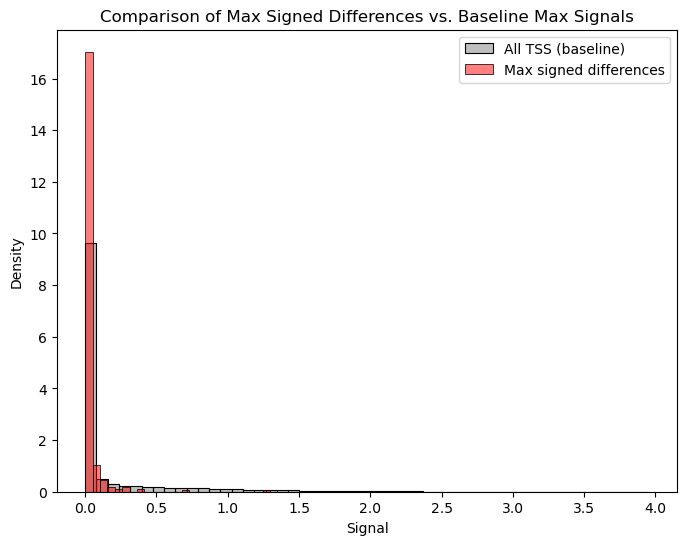

In [24]:
# Two distributions overlaid
plt.figure(figsize=(8,6))
sns.histplot(tss_df["max_signal"], color="gray", label="All TSS (baseline)", kde=False, stat="density", bins=50, alpha=0.5)
sns.histplot(df["max_signed_diff"], color="red", label="Max signed differences", kde=False, stat="density", bins=25, alpha=0.5)

plt.xlabel("Signal")
plt.ylabel("Density")
plt.legend()
plt.title("Comparison of Max Signed Differences vs. Baseline Max Signals")
plt.show()

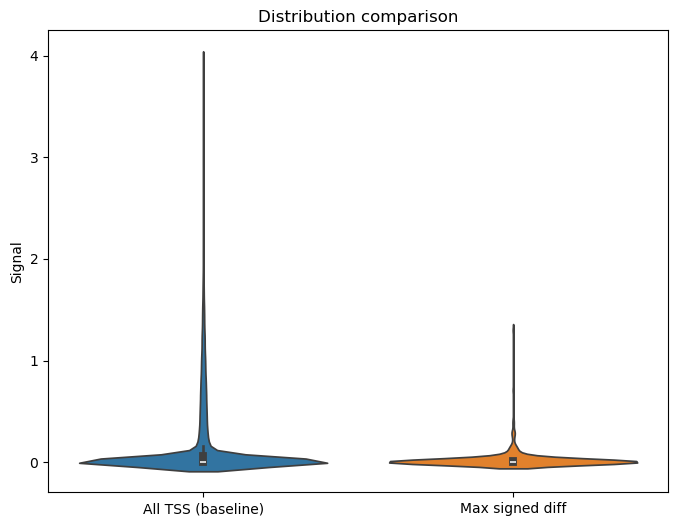

In [25]:
plt.figure(figsize=(8,6))
sns.violinplot(data=[tss_df["max_signal"], df["max_signed_diff"]], inner="box")
plt.xticks([0,1], ["All TSS (baseline)", "Max signed diff"])
plt.ylabel("Signal")
plt.title("Distribution comparison")
plt.show()

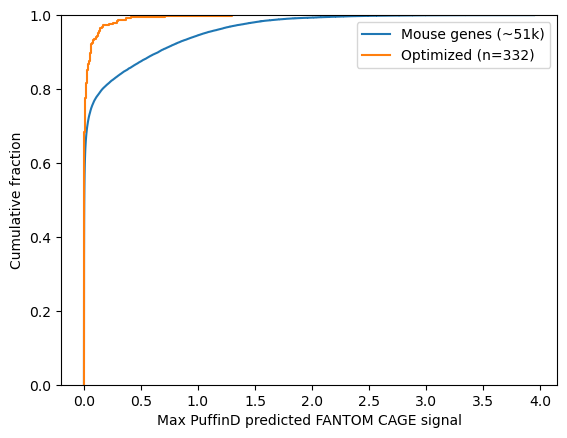

In [26]:
sns.ecdfplot(tss_df["max_signal"], label="Mouse genes (~51k)")
sns.ecdfplot(df["max_after"], label="Optimized (n=332)")
plt.xlabel("Max PuffinD predicted FANTOM CAGE signal")
plt.ylabel("Cumulative fraction")
plt.legend()
plt.show()

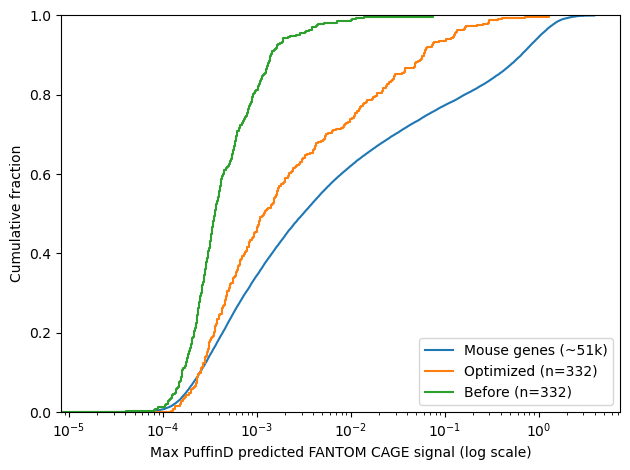

In [27]:
sns.ecdfplot(tss_df["max_signal"], label="Mouse genes (~51k)")
sns.ecdfplot(df["max_after"], label="Optimized (n=332)")
sns.ecdfplot(df["max_before"], label="Before (n=332)")

plt.xscale("log")  # log-transform x-axis
plt.xlabel("Max PuffinD predicted FANTOM CAGE signal (log scale)")
plt.ylabel("Cumulative fraction")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# Your arrays
before = np.array(df["max_before"])       # n=311
after = np.array(df["max_after"])         # n=311
genes = np.array(tss_df["max_signal"])    # n=51000

# Convert back to raw reads
before_reads = 10**before - 1
after_reads = 10**after - 1
genes_reads = 10**genes - 1

In [32]:
before_reads.max(), after.max(), genes_reads.max()

(0.1887945, 1.2994016, 8985.8711060436)

In [33]:
# Prepare dataframe
plot_df = pd.DataFrame({
    "Reads": np.concatenate([before_reads, after_reads, genes_reads]),
    "Group": ["Before"]*len(before_reads) + ["After"]*len(after_reads) + ["Genes"]*len(genes_reads)
})

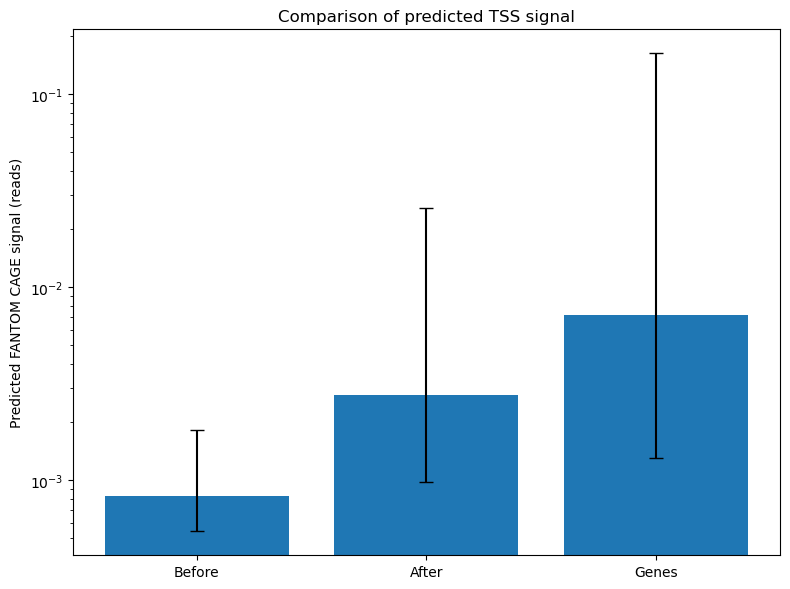

In [38]:
# Specify desired order
group_order = ["Before", "After", "Genes"]

# Compute summary statistics in the desired order
summary = plot_df.groupby("Group")["Reads"].agg(
    median="median",
    q25=lambda x: np.percentile(x, 25),
    q75=lambda x: np.percentile(x, 75)
).reindex(group_order).reset_index()

# Plot as barplot (median with IQR as error bars) in blue
plt.figure(figsize=(8,6))
plt.bar(summary["Group"], summary["median"], 
        yerr=[summary["median"] - summary["q25"], summary["q75"] - summary["median"]],
        capsize=5)

plt.yscale("log")  # log scale for better visibility
plt.ylabel("Predicted FANTOM CAGE signal (reads)")
plt.title("Comparison of predicted TSS signal")
plt.tight_layout()

plt.savefig("puffin_reads_barplot.svg", format='svg')

plt.show()

In [37]:
# Compute for max_before
before_values = before_reads
before_percentiles = np.percentile(before_values, [25, 50, 75])
before_mean = np.mean(before_values)
print(f"max_before: mean={before_mean:.7f}, 25th={before_percentiles[0]:.7f}, median={before_percentiles[1]:.7f}, 75th={before_percentiles[2]:.7f}")

# Compute for max_after
after_values = after_reads
after_percentiles = np.percentile(after_values, [25, 50, 75])
after_mean = np.mean(after_values)
print(f"max_after: mean={after_mean:.7f}, 25th={after_percentiles[0]:.7f}, median={after_percentiles[1]:.7f}, 75th={after_percentiles[2]:.7f}")


max_before: mean=0.0023592, 25th=0.0005434, median=0.0008251, 75th=0.0018182
max_after: mean=0.1241092, 25th=0.0009787, median=0.0027689, 75th=0.0258687


In [ ]:
# Plot pile-up
plt.figure(figsize=(12,5))
x = np.arange(len(avg_diff))
plt.plot(x, avg_diff, color="darkorange", label="Optimized - Original (mean)")
plt.fill_between(x, avg_diff - sem_diff, avg_diff + sem_diff, 
                 color="darkorange", alpha=0.3, label="± SEM")
plt.axhline(0, color="black", linestyle="--", lw=1)
plt.xlabel("Position (bp)")
plt.ylabel("Δ FANTOM CAGE prediction")
plt.title("Pile-up of signal differences across sequences")
plt.legend()
plt.tight_layout()
plt.show()

### Example plots for significant differences

In [ ]:
for i, row in df[:3].iterrows():
    chrom = row['chrom']
    centered_start = int(row['centered_start'])
    centered_end = int(row['centered_end'])
    
    orig = np.load(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/original_preds/{chrom}_{centered_start}_{centered_end}_original.npy")[0, 0, flank:-flank] 
    opt  = np.load(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/optimized_preds/{chrom}_{centered_start}_{centered_end}_optimized.npy")[0, 0, flank:-flank]
    
    plt.figure(figsize=(12, 4))
    plt.plot(orig, label="Original", color="blue")
    plt.plot(opt, label="Optimized", color="red")
    plt.title(f"Sequence {chrom}: {centered_start}-{centered_end}")
    plt.xlabel("Position")
    plt.ylabel("FANTOM CAGE prediction")
    plt.legend()
    plt.show()

# Non-significant differences examples

In [ ]:
nonsign = df[df["reject_null"] == False].reset_index(drop=True)

In [ ]:
for i, row in nonsign[:3].iterrows():
    chrom = row['chrom']
    centered_start = int(row['centered_start'])
    centered_end = int(row['centered_end'])
    
    orig = np.load(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/original_preds/{chrom}_{centered_start}_{centered_end}_original.npy")[0, 0, flank:-flank] 
    opt  = np.load(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/optimized_preds/{chrom}_{centered_start}_{centered_end}_optimized.npy")[0, 0, flank:-flank]
    
    plt.figure(figsize=(12, 4))
    plt.plot(orig, label="Original", color="blue")
    plt.plot(opt, label="Optimized", color="red")
    plt.title(f"Sequence {chrom}: {centered_start}-{centered_end}")
    plt.xlabel("Position")
    plt.ylabel("FANTOM CAGE prediction")
    plt.legend()
    plt.show()